In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('../../PerturbVAE/')

from model import *
from utils import *
from dataset import *
from train import *

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = sc.read_h5ad('data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [27]:
sc.pp.normalize_total(data)
sc.pp.log1p(data)
sc.pp.pca(data)

sc.pp.neighbors(data)
sc.tl.umap(data)

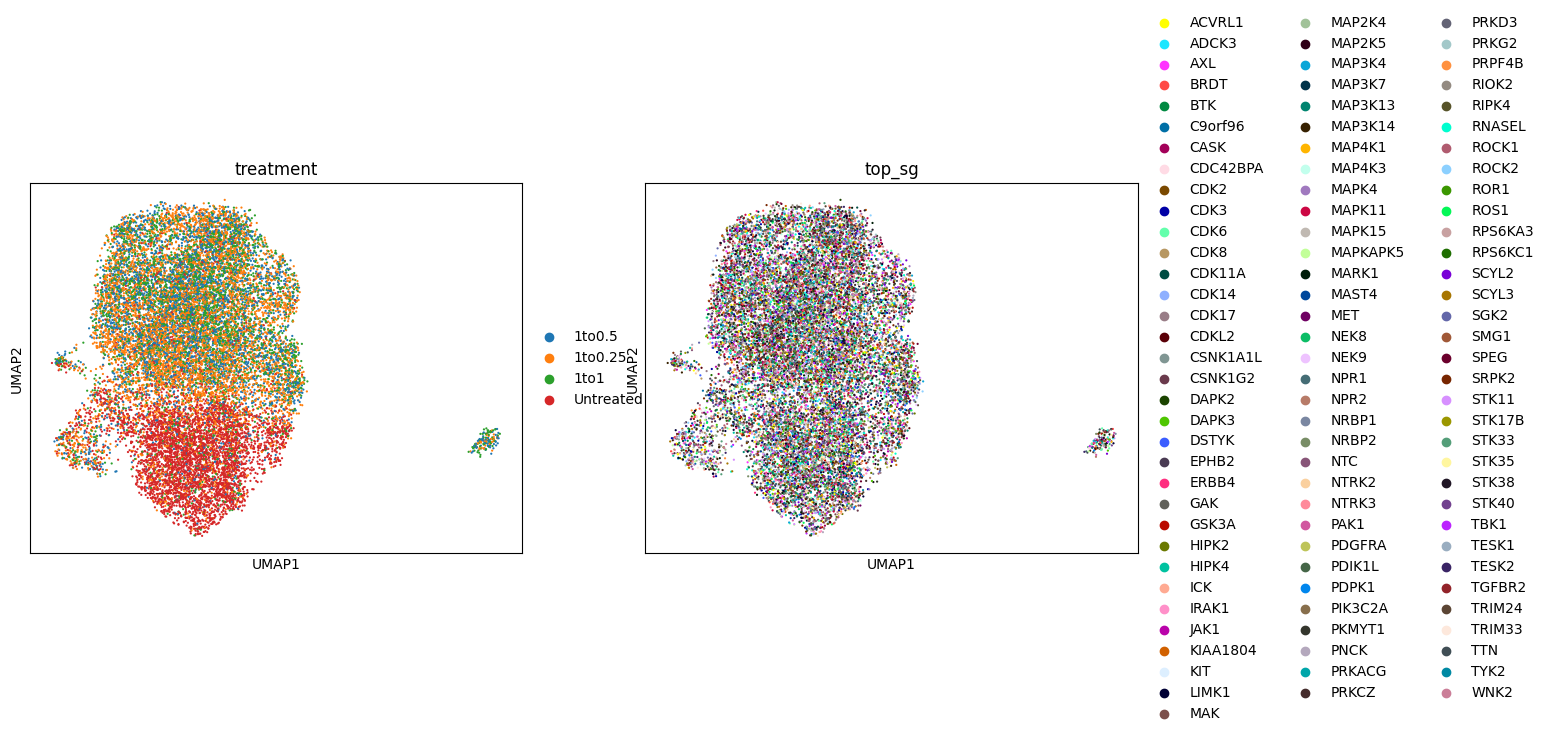

In [28]:
sc.pl.umap(data, color=['treatment', 'top_sg'], size=10)

In [3]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

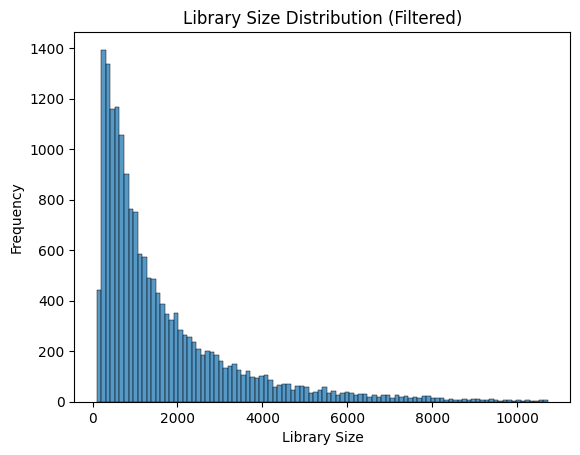

In [45]:
sns.histplot(data.obs['library_size'], bins=100)
plt.xlabel('Library Size')
plt.ylabel('Frequency')
plt.title('Library Size Distribution (Filtered)')
plt.show()

In [40]:
theta = torch.tensor([1.5])
mu = torch.tensor([2000])
EPS = 1e-6
logits = mu.log() - theta.log()

nb_dist = dist.NegativeBinomial(total_count=theta, logits=logits)

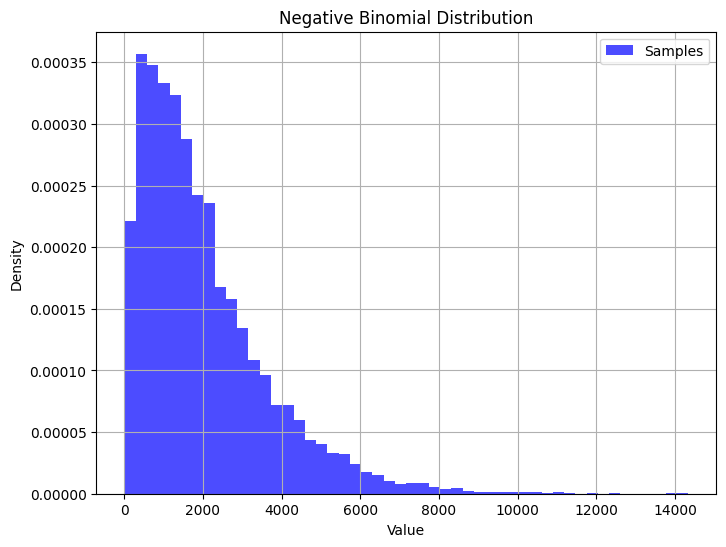

In [41]:
import matplotlib.pyplot as plt

# Sample from the negative binomial distribution
samples = nb_dist.sample((10000,))

# Plot the histogram of the samples
plt.figure(figsize=(8, 6))
plt.hist(samples.numpy(), bins=50, density=True, alpha=0.7, color='blue', label='Samples')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Negative Binomial Distribution')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
dataset = PerturbDataset(data)

In [5]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
# ----------------------------------------------------------------------
# 1. GLOBAL DEBUG SWITCHES
# ----------------------------------------------------------------------
import warnings, math, functools, inspect, builtins
import pyro, torch

torch.autograd.set_detect_anomaly(True)          # traces op that first returns NaN / Inf
pyro.enable_validation(True)                     # Pyro distributions raise on bad params

def _dbg(name, t):
    """Print shape/range + assert finite."""
    if isinstance(t, torch.Tensor):
        if not torch.isfinite(t).all():
            bad = t[~torch.isfinite(t)]
            print(f"[NaN‑DEBUG] {name} has {bad.numel()} non‑finite values. "
                  f"Min={bad.min().item() if bad.numel() else 'NA'} "
                  f"Max={bad.max().item() if bad.numel() else 'NA'} "
                  f"Example={bad.flatten()[0].item() if bad.numel() else 'NA'}")
            raise ValueError(f"NaN or Inf detected in {name}")
        else:
            # comment‑out next line if it is too chatty
            print(f"[OK] {name:15s}  shape={tuple(t.shape)} "
                  f"range=({t.min().item():.3g}, {t.max().item():.3g})")
    return t
# ----------------------------------------------------------------------


In [26]:
import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch

import pyro.distributions as dist
import torch.nn as nn
from tqdm import tqdm  # Import tqdm for progress bar
from sklearn.metrics import r2_score


# Define the VAE model
class BasicVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, perturbs, conds, beta):
        super(BasicVAE, self).__init__()

        self.beta = beta
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.conds = conds
        self.perturbs = perturbs
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.p_emb = nn.Embedding(perturbs, latent_dim)
        self.c_emb = nn.Embedding(conds, latent_dim)

        # Encoder: q(z|x,p)
        self.z_encoder = nn.Sequential(
            nn.Linear(input_dim+latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 2 * latent_dim)  # Outputs mean and log variance
        )

        # Encoder: q(z0|x,c)
        self.z0_encoder = nn.Sequential(
            nn.Linear(input_dim+latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 2 * latent_dim)  # Outputs mean and log variance
        )

        # Decoder: p(z|z0)
        self.z0_decoder = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.LeakyReLU(),
            nn.Linear(latent_dim, 2 * latent_dim),
        )

        # Decoder: p(x|z)
        self.z_decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, input_dim),
        )

        # Initialize weights
        self._initialize_weights()

        self.mu = None
        self.total_counts = None
    
    def _initialize_weights(self):
        # Initialize encoder weights
        for layer in self.z_encoder:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        # Initialize decoder weights
        for layer in self.z_decoder:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def model(self, x, p, c):
        pyro.module("z_decoder", self.z_decoder)
        pyro.module("z_decoder", self.z0_decoder)

        theta = pyro.param(
            "theta",
            torch.ones(self.input_dim, device=self.device) * 1.0,
            constraint=constraints.positive,
        )

        z0_mean = pyro.param(
            "z0_mean",
            torch.zeros((self.conds, self.latent_dim), device=self.device),
        )
        z0_var = pyro.param(
            "z0_var",
            torch.ones((self.conds, self.latent_dim), device=self.device),
            constraint=constraints.positive
        )

        with pyro.plate("cells", x.size(0)):
            z0_loc   = x.new_zeros((x.size(0), self.latent_dim))
            z0_scale = x.new_ones((x.size(0), self.latent_dim))

            z0 = pyro.sample("z0",
                            dist.Normal(z0_loc, z0_scale).to_event(1))
            # _dbg("z", z)

            
            z_loc, z_logvar = self.z0_decoder(z0).chunk(2, dim=-1)
            z = pyro.sample("z",
                            dist.Normal(z_loc, (0.5 * z_logvar).exp()).to_event(1))

            logits_gene = self.z_decoder(z)
            # _dbg("logits_gene", logits_gene)

            mu = torch.softmax(logits_gene, dim=-1)
            # _dbg("mu", mu)

            total_counts = x.sum(-1, keepdim=True)
            # _dbg("total_counts", total_counts)

            self.mu = mu.clone().detach().to('cpu').numpy()
            self.total_counts = total_counts.clone().detach().to('cpu').numpy()

            x_mu = total_counts * mu
            # _dbg("x_mu", x_mu)

            logits = (x_mu + 1e-6).log() - (theta + 1e-6).log()
            # _dbg("logits", logits)

            nb = dist.NegativeBinomial(total_count=theta, logits=logits)
            pyro.sample("X", nb.to_event(1), obs=x.float())

    # ---------------- GUIDE ----------------
    def guide(self, x, p, c):
        pyro.module("z_encoder", self.z_encoder)
        pyro.module("z0_encoder", self.z0_encoder)

        with pyro.plate("cells", x.size(0)):

            inp = torch.cat([x, vae.p_emb(p)], dim=-1)
            params = self.z_encoder(inp)
            z_mu, z_logvar = params.chunk(2, dim=-1)
            std = (0.5 * z_logvar).exp()
            z = pyro.sample("z", dist.Normal(z_mu, std+1e-6).to_event(1))

            inp = torch.cat([x, vae.c_emb(c)], dim=-1)
            params = self.z0_encoder(inp)
            z0_mu, z0_logvar = params.chunk(2, dim=-1)
            std = (0.5 * z0_logvar).exp()
            pyro.sample("z0", dist.Normal(z0_mu, std+1e-6).to_event(1))


# Initialize the VAE
pyro.clear_param_store()

input_dim = data.shape[-1] 
latent_dim = 16
vae = BasicVAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 100)
vae = vae.to(vae.device)

# Optimizer and SVI
optimizer = Adam({"lr": 1e-3}) #3 works
svi = SVI(vae.model, vae.guide, optimizer, loss=Trace_ELBO())

# Example training loop
print("Training VAE...", vae.device)
num_epochs = 10
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    all_actuals = []
    all_predictions = []
    for X, P, C in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False):
        # Move data to the same device as the model
        X = X.to(vae.device).float()
        P = P.to(vae.device).int()
        C = C.to(vae.device).int()
        
        loss = svi.step(X, P, C)
        epoch_loss += loss
        losses.append(loss)

        with torch.no_grad():
            z_loc, _ = vae.z_encoder(torch.cat([X,vae.p_emb(P)], dim=-1)).chunk(2, dim=-1)  # Latent space
            decoded_logits = vae.z_decoder(z_loc)               # Reconstructed data
            mu = torch.softmax(decoded_logits, dim=-1)
            total_counts = X.sum(-1, keepdim=True)
            x_mu = total_counts * mu

            all_actuals.append(X.cpu().numpy())
            all_predictions.append(x_mu.cpu().numpy())

    # Calculate R² at the end of the epoch
    all_actuals = np.concatenate(all_actuals, axis=0)
    all_predictions = np.concatenate(all_predictions, axis=0)
    r2 = r2_score(all_actuals.flatten(), all_predictions.flatten())

    print(f"Epoch {epoch + 1}, Loss: {epoch_loss / dataset.X.shape[0]:.4f}, R²: {r2:.4f}")

Training VAE... cuda


Epoch 1, Loss: 2375.3906, R²: 0.3322


Epoch 2, Loss: 1912.9582, R²: 0.5864


Epoch 3, Loss: 1889.3480, R²: 0.6399


Epoch 4, Loss: 1865.8213, R²: 0.6691


...

Epoch 6, Loss: 1836.2637, R²: 0.6967


Epoch 7, Loss: 1810.6867, R²: 0.7076


Epoch 8, Loss: 1795.0294, R²: 0.7152


Epoch 9, Loss: 1789.6285, R²: 0.7204


Epoch 10, Loss: 1784.9405, R²: 0.7247


In [ ]:
import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch

import pyro.distributions as dist
import torch.nn as nn
from tqdm import tqdm  # Import tqdm for progress bar
from sklearn.metrics import r2_score


# Define the VAE model
class BasicVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, perturbs, conds, beta):
        super(BasicVAE, self).__init__()

        pyro.module("PerturbVAE", self)

        self.beta = beta
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.perturbs = perturbs
        self.conds = conds
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.p_emb = nn.Embedding(perturbs, latent_dim)
        self.c_emb = nn.Embedding(conds, latent_dim)

        # Encoder: q(z|x,p)
        self.z_encoder = nn.Sequential(
            nn.Linear(input_dim+2*latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 2 * latent_dim)  # Outputs mean and log variance
        )

        # Encoder: q(z0|x,c)
        self.z0_encoder = nn.Sequential(
            nn.Linear(input_dim+latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 2 * latent_dim)  # Outputs mean and log variance
        )

        # Decoder: p(z|z0)
        self.z0_decoder = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.LeakyReLU(),
            nn.Linear(latent_dim, latent_dim),
        )

        # Decoder: p(x|z)
        self.z_decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, input_dim),
        )

        # Initialize weights
        self._initialize_weights()

        self.mu = None
        self.total_counts = None
    
    def _initialize_weights(self):
        # Initialize encoder weights
        for layer in self.z_encoder:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        for layer in self.z0_encoder:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        # Initialize decoder weights
        for layer in self.z0_decoder:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        for layer in self.z_decoder:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def model(self, x, p, c):
        pyro.module("decoder", self.z_decoder)

        theta = pyro.param(
            "theta",
            torch.ones(self.input_dim, device=self.device) * 1.0,
            constraint=constraints.positive,
        )

        # z0_mean = pyro.param(
        #     "z0_mean",
        #     torch.zeros((self.conds, self.latent_dim), device=self.device),
        # )
        # z0_var = pyro.param(
        #     "z0_var",
        #     torch.ones((self.conds, self.latent_dim), device=self.device),
        #     constraint=constraints.positive
        # )

        # _dbg("theta", theta)

        with pyro.plate("cells", x.size(0)):

            # control cells
            # z_0 = pyro.sample("z0", dist.Normal(z0_mean[C], (z0_var[C]/2).exp()).to_event(1)) # B x n_modules

            # z_loc, z_scale = self.z0_decoder(z_0).chunk(2, dim=-1)
            # z = pyro.sample("z",
            #                 dist.Normal(z_loc, (z_scale/2).exp()).to_event(1))

            z_loc   = x.new_zeros((x.size(0), self.latent_dim))
            z_scale = x.new_ones((x.size(0), self.latent_dim))

            z = pyro.sample("z",
                            dist.Normal(z_loc, z_scale).to_event(1))

            # _dbg("z", z)

            logits_gene = self.z_decoder(z)
            # _dbg("logits_gene", logits_gene)

            mu = torch.softmax(logits_gene, dim=-1)
            # _dbg("mu", mu)

            total_counts = x.sum(-1, keepdim=True)
            # _dbg("total_counts", total_counts)

            self.mu = mu.clone().detach().to('cpu').numpy()
            self.total_counts = total_counts.clone().detach().to('cpu').numpy()

            x_mu = total_counts * mu
            # _dbg("x_mu", x_mu)

            logits = (x_mu + 1e-6).log() - (theta + 1e-6).log()
            # _dbg("logits", logits)

            nb = dist.NegativeBinomial(total_count=theta, logits=logits)
            pyro.sample("X", nb.to_event(1), obs=x.float())

    # ---------------- GUIDE ----------------
    def guide(self, x, p, c):
        pyro.module("encoder", self.z_encoder)

        with pyro.plate("cells", x.size(0)):
            z_inp = torch.cat([x, vae.p_emb(p), vae.c_emb(c)], dim=-1)
            z_mu, z_logvar = self.z_encoder(z_inp).chunk(2, dim=-1)

            pyro.sample("z", dist.Normal(z_mu, (z_logvar/2).exp()).to_event(1))

            # z0_inp = torch.cat([x, vae.c_emb(c)], dim=-1)
            # z0_mu, z0_logvar = self.z0_encoder(z0_inp).chunk(2, dim=-1)

            # pyro.sample("z0", dist.Normal(z0_mu, (z0_logvar/2).exp()).to_event(1))


# Initialize the VAE
pyro.clear_param_store()

input_dim = data.shape[-1] 
latent_dim = 16
vae = BasicVAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 100)
vae = vae.to(vae.device)

# Optimizer and SVI
optimizer = Adam({"lr": 1e-3}) #3 works
svi = SVI(vae.model, vae.guide, optimizer, loss=Trace_ELBO())

# Example training loop
print("Training VAE...", vae.device)
num_epochs = 10
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    all_actuals = []
    all_predictions = []
    for X, P, C in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False):
        # Move data to the same device as the model
        X = X.to(vae.device).float()
        P = P.to(vae.device).int()
        C = C.to(vae.device).int()
        
        loss = svi.step(X, P, C)
        epoch_loss += loss
        losses.append(loss)

        with torch.no_grad():
            z_loc, _ = vae.z_encoder(torch.cat([X,vae.p_emb(P),vae.c_emb(C)], dim=-1)).chunk(2, dim=-1)  # Latent space
            decoded_logits = vae.z_decoder(z_loc)               # Reconstructed data
            mu = torch.softmax(decoded_logits, dim=-1)
            total_counts = X.sum(-1, keepdim=True)
            x_mu = total_counts * mu

            all_actuals.append(X.cpu().numpy())
            all_predictions.append(x_mu.cpu().numpy())

    # Calculate R² at the end of the epoch
    all_actuals = np.concatenate(all_actuals, axis=0)
    all_predictions = np.concatenate(all_predictions, axis=0)
    r2 = r2_score(all_actuals.flatten(), all_predictions.flatten())

    print(f"Epoch {epoch + 1}, Loss: {epoch_loss / dataset.X.shape[0]:.4f}, R²: {r2:.4f}")

In [52]:
    from scvi.model import SCVI
    SCVI.setup_anndata(data)

/opt/conda/envs/perturb/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/conda/envs/perturb/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [53]:
model = SCVI(data)
model.to_device("cuda:0")
model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/envs/perturb/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 27/400:   6%|▋         | 26/400 [00:41<09:55,  1.59s/it, v_num=1, train_loss_step=1.62e+3, train_loss_epoch=1.72e+3]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [59]:
vae.total_counts.max()

np.float32(26883.0)

In [ ]:
vae.t

In [ ]:
vae.mu.min(), vae.mu.max(), vae.mu.mean(), vae.mu.std()


total_counts = x.sum(-1, keepdim=True)
_dbg("total_counts", total_counts)

self.mu = mu.clone().detach().to('cpu').numpy()
x_mu = total_counts * mu
_dbg("x_mu", x_mu)

logits = (x_mu + 1e-6).log() - (theta + 1e-6).log()
_dbg("logits", logits)

nb = dist.NegativeBinomial(total_count=theta, logits=logits)
pyro.sample("X", nb.to_event(1), obs=x.float())

(np.float32(0.0),
 np.float32(0.99996996),
 np.float32(0.00045085663),
 np.float32(0.0018895521))

In [ ]:
# from importlib import reload

# from model import PerturbVAE

# import model as m

# reload(m)

In [ ]:
pyro.clear_param_store()

config = LitConfig()
config.lr = 1e-4

hyper_config = HyperparamConfig()
hyper_config.n_genes = data.shape[-1]
hyper_config.n_conditions = len(np.unique(dataset.C_indices))
hyper_config.n_perturb = len(np.unique(dataset.P_indices))

model = PerturbVAE(config=hyper_config)
trainer_config = TrainerConfig()
trainer_config.max_epochs = 10
trainer_config.force_cpu = False

train_(model, config, dataloader, val_loader=None, trainer_config=trainer_config)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/envs/perturb/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
/opt/conda/envs/perturb/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type       | Params | Mode 
--------------------------------------------------
0 | full_model | PerturbVAE | 1.7 M  | train
1 | predictive | Predictive | 0      | train
--------------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M

Epoch 0:  49%|████▉     | 69/141 [00:02<00:02, 30.69it/s, v_num=zskl]


Detected KeyboardInterrupt, attempting graceful shutdown ...


torch.Size([128, 4]) torch.Size([128])


NameError: name 'exit' is not defined

In [ ]:
import pyro.poutine as poutine

model.device = torch.device('cpu')
model.eval()
model = model.to(model.device)


X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

trace = poutine.trace(model.guide).get_trace(X, P, C)



In [ ]:
z = trace.nodes["z"]["value"]
mu = model.z_dec(z)

l = X.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

In [ ]:
correct = 0
total   = 0

logits = model.pertubation_head(z) 
y_pred = logits.argmax(dim=-1) 
correct += (y_pred == P).sum().item()
total   += P.size(0)

accuracy = correct / total
print(f"Classification accuracy: {accuracy:.4f}")

Classification accuracy: 0.0109


/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


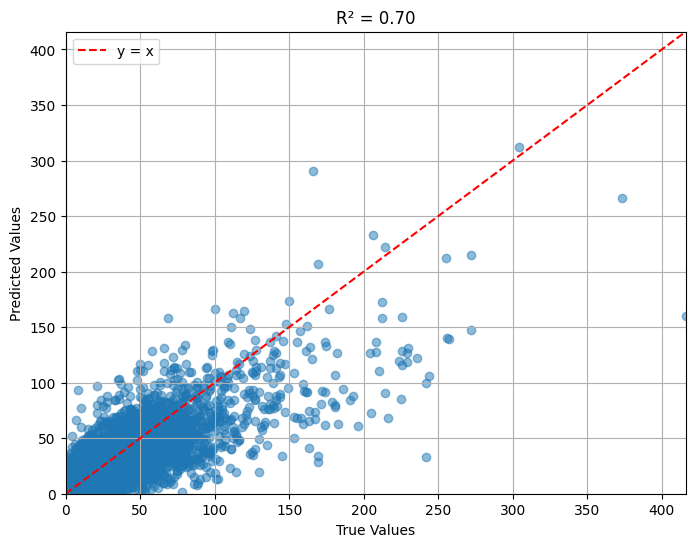

In [67]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# prediction = model.nb_logger

r2 = r2_score(dataset.X.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, dataset.X.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = dataset.X[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
rho = trace.nodes["rho"]["value"]

batch_indices = torch.arange(rho.size(0))
rho_at_P = rho[batch_indices, P, :]  # shape: [batch, latent_dim]

data.obsm['rho'] = rho_at_P.detach().cpu().numpy()


In [ ]:
z = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

In [ ]:
z_data = data.copy()
z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, use_rep='z', n_neighbors=15)
sc.tl.umap(z_data)

In [ ]:
z0_data = data.copy()
z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='z0', n_neighbors=15)
sc.tl.umap(z0_data)

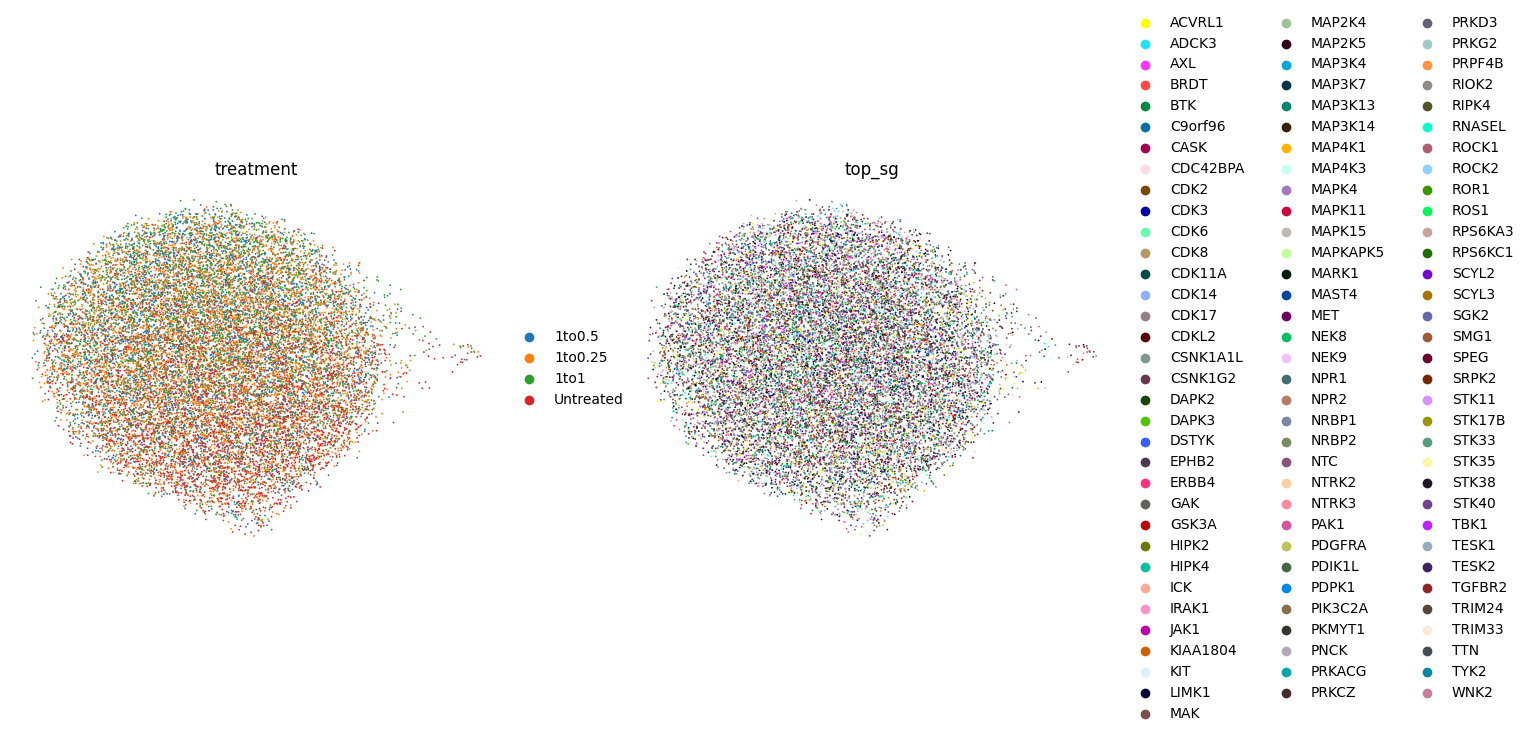

In [ ]:
sc.pl.umap(z_data, color=['treatment', 'top_sg'], frameon=False, show=True)

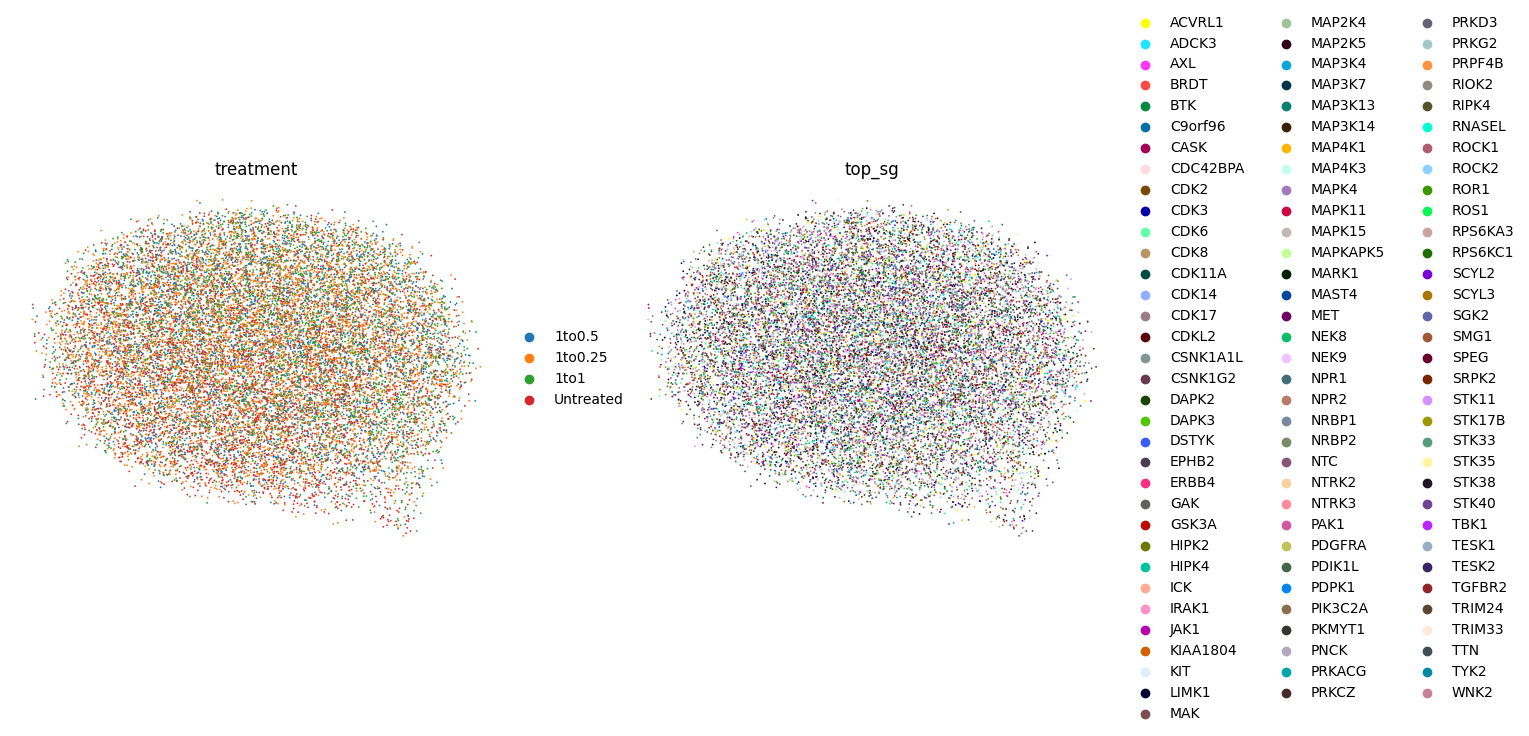

In [ ]:
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [ ]:
sc.pp.neighbors(data, use_rep='rho', n_neighbors=15)

sc.tl.leiden(data, resolution=1.0)
sc.tl.umap(data)

/var/tmp/ipykernel_356421/857645755.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(data, resolution=1.0)


In [ ]:
np.sum(data.obs.top_sg == 'NTC')

np.int64(416)

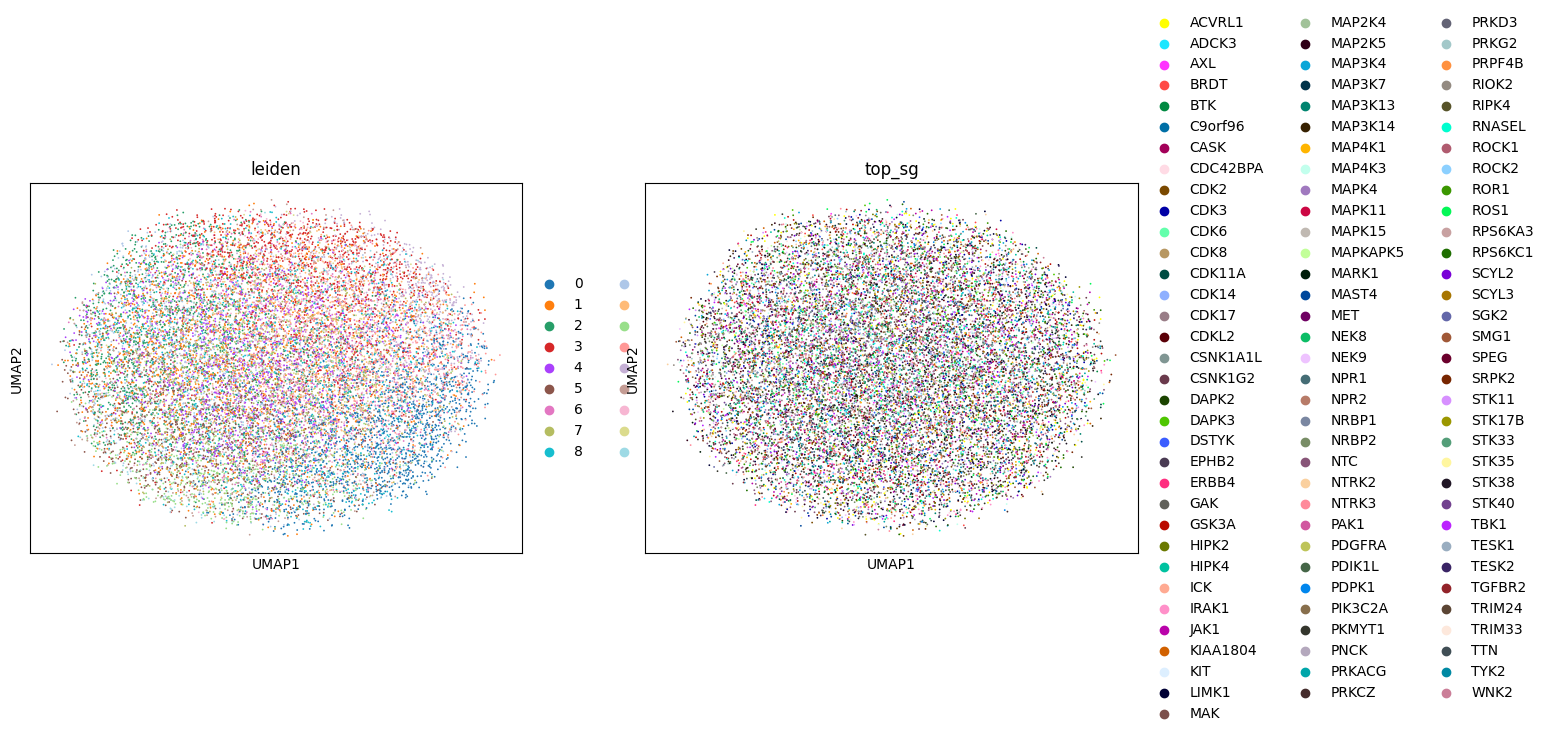

In [ ]:
sc.pl.umap(data, color=['leiden', 'top_sg'])